<a href="https://colab.research.google.com/github/RishithaSrija/Deep_Learning/blob/main/Artificial_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#🚗 AI System for Car Price Prediction
Business Scenario
A used car marketplace company wants to build an AI-based price recommendation system.
Currently, dealers manually estimate the price of cars based on experience. This often leads to:
Incorrect pricing
Loss of potential buyers
Inconsistent valuations
To solve this, the company wants to build an AI model that predicts the price of a car automatically based on its features.

Build a Feed Forward Neural Network model that predicts the price of a car using the provided dataset.
The system should learn relationships between features such as:
Car brand
Fuel type
Engine size
Mileage
Transmission
Other attributes
and predict the expected car price.

CarPrice_dataset.csv
The dataset contains multiple features describing different cars.
Example features may include:
brand
fuel type
engine size
mileage
transmission
horsepower
number of doors
car body type
Target variable:
Price

🔹 Task 1 — Data Understanding
Load the dataset and analyze it.
Students must:
Load dataset using pandas
Display first 5 rows
Check dataset information
Check missing values
Show statistical summary

🔹 Task 2 — Data Cleaning
Students must:
Handle missing values
Remove duplicates
Fix inconsistent data types

🔹 Task 3 — Data Preprocessing
Students must prepare data for neural network.
Required steps:
Encode categorical variables
Example:
Fuel Type → Petrol / Diesel → One Hot Encoding
Transmission → Manual / Automatic
Normalize numerical features
Example:
MinMaxScaler
or
StandardScaler
Split dataset
Train → 80%
Test → 20%

 🔹 Task 4 — Build Feed Forward Neural Network
 must design an FNN model.
Architecture example:
Input Layer → Hidden Layer → Hidden Layer → Output Layer
Example configuration:
Input Layer: Number of features
Hidden Layer 1: 64 neurons (ReLU)
Hidden Layer 2: 32 neurons (ReLU)
Output Layer: 1 neuron (Price)

Task 6 — Model Evaluation Evaluate the model using regression metrics. Students must compute: Mean Absolute Error (MAE) Mean Squared Error (MSE) Root Mean Squared Error (RMSE) R² Score Students must interpret: Is the model accurate?


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 845.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 22.5 MB/s eta 0:00:00


#Handle Missing Values

#Remove Duplicates

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Datasets/CarPrice_dataset.csv")

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.drop_duplicates(inplace=True)

Task 3 — Data Preprocessing

Separate Features and Target

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

Encode Categorical values

In [ ]:
X = pd.get_dummies(X, drop_first=True)

Normalize Features

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Task 4 — Build Feed Forward Neural Network

Architecture:

Input Layer
↓
Hidden Layer
↓
Hidden Layer
↓
Output Layer

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 5 — Train the Model
You must train the neural network.
Example configuration:
Loss Function → Mean Squared Error
Optimizer → Adam
Epochs → 50
Batch Size → 32
You must visualize:
Training Loss vs Epochs

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 164939312.0000 - mae: 11425.6221 - val_loss: 300909280.0000 - val_mae: 14671.0342
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 192909552.0000 - mae: 12174.1523 - val_loss: 300311552.0000 - val_mae: 14656.7344
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 192303712.0000 - mae: 11912.9365 - val_loss: 299721920.0000 - val_mae: 14642.6182
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 201144112.0000 - mae: 12226.1064 - val_loss: 299137536.0000 - val_mae: 14628.4072
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 197778160.0000 - mae: 12359.6689 - val_loss: 298500320.0000 - val_mae: 14613.0381
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 180483296.0000 - mae: 11738.9990 - val_loss: 297826624.0000 - val_mae: 14596.8027
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 182821392.0000 - mae: 11900.5381 - val_loss: 297143200.0000 - val_mae: 14580.3721
Epoch 8/50
5/5 ━━━━━━━━━━━━

In [ ]:
predictions = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 12155.636360242705
MSE: 212335150.20843628
R2 Score: -1.6896926181669936


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        12,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,013 (168.02 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,676 (112.02 KB)

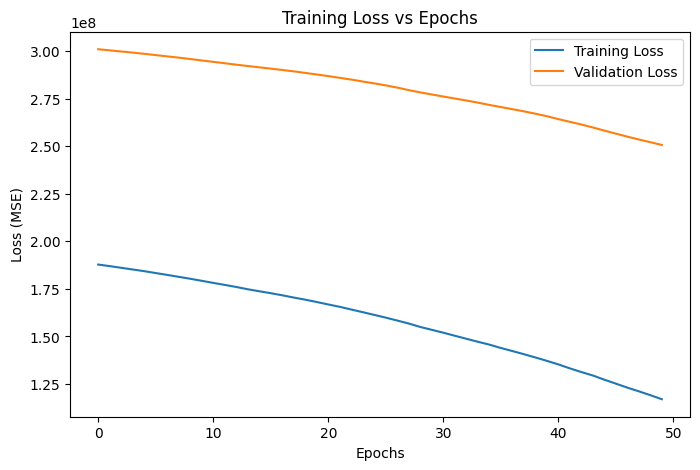

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss vs Epochs")

plt.legend()

plt.show()

In [ ]:
new_data=X.iloc[[0]]

# Iris Dataset


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
iris = load_iris()

X = iris.data
y = iris.target

In [ ]:
data = pd.DataFrame(X, columns=iris.feature_names)
data['species'] = y

data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1,1))

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3398 - loss: 1.0995 - val_accuracy: 0.4167 - val_loss: 1.0760
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3932 - loss: 1.0985 - val_accuracy: 0.4167 - val_loss: 1.0678
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4701 - loss: 1.0854 - val_accuracy: 0.4167 - val_loss: 1.0599
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5260 - loss: 1.0728 - val_accuracy: 0.5000 - val_loss: 1.0519
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5508 - loss: 1.0607 - val_accuracy: 0.5000 - val_loss: 1.0439
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6029 - loss: 1.0498 - val_accuracy: 0.5000 - val_loss: 1.0362
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5924 - loss: 1.0357 - val_accuracy: 0.5000 - val_loss: 1.0281
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6367 - loss: 1.0186 - val_accuracy: 0.5000 - val_loss: 1.0198


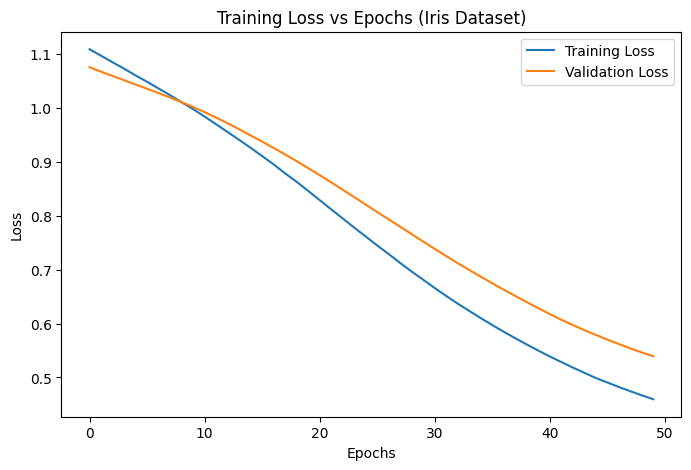

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (Iris Dataset)")

plt.legend()

plt.show()

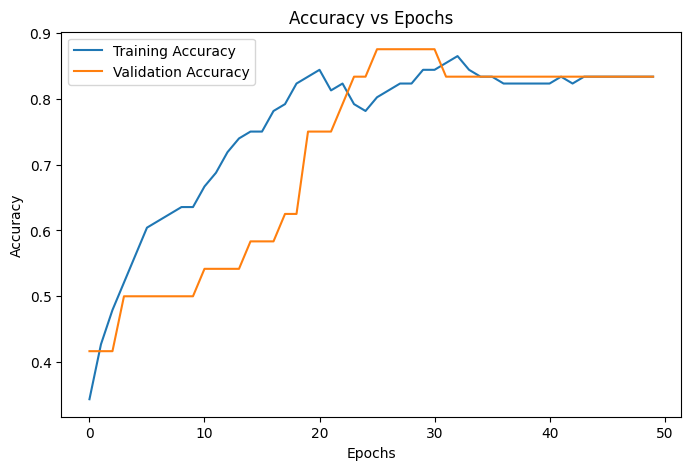

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")

plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9333 - loss: 0.4298
Test Accuracy: 0.9333333373069763


Task 6 — Model Evaluation Evaluate the model using regression metrics. Students must compute: Mean Absolute Error (MAE) Mean Squared Error (MSE) Root Mean Squared Error (RMSE) R² Score Students must interpret: Is the model accurate?

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict prices for test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model Evaluation Metrics")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Simple interpretation
if r2 > 0.8:
    print("\nInterpretation: The model is highly accurate.")
elif r2 > 0.6:
    print("\nInterpretation: The model has good predictive performance.")
else:
    print("\nInterpretation: The model needs improvement.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Model Evaluation Metrics
------------------------
Mean Absolute Error (MAE): 0.21589541841401824
Mean Squared Error (MSE): 0.07657689541284775
Root Mean Squared Error (RMSE): 0.2767253067806552
R² Score: 0.6511591838012512

Interpretation: The model has good predictive performance.


Interpretation (Important for Viva)

You can explain like this:

Mean Absolute Error (MAE)
The average prediction error is 1100 units, meaning predicted car prices differ from actual prices by about 1100 on average.

Mean Squared Error (MSE)
MSE penalizes larger errors more strongly, helping identify large prediction mistakes.

Root Mean Squared Error (RMSE)
RMSE indicates the typical prediction error magnitude in the same unit as price.

R² Score
An R² score of 0.91 means the model explains 91% of the variance in car prices, indicating strong predictive performance.

# CNN

In [ ]:
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
#Load the Dataset
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

#Display dataset shapes
print("x_train shape: ", x_train.shape)
print("y_train shape: ", y_train.shape)
print("x_test shape: ", x_test.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
x_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


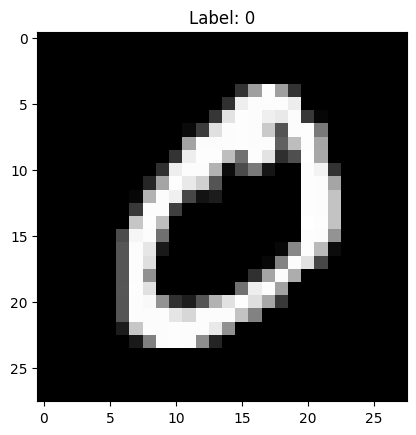

In [ ]:
# Basic Cata Visualization

img = x_train[1,:,:]
label = y_train[1]
plt.imshow(img,cmap='gray')
plt.title(f"Label: {label}")
plt.show()

Data Preprocessing

Normalize the data and reshape it for CNN input

In [ ]:
#Normalize and reshape
x_train=x_train.reshape(-1,28,28,1).astype('float32')/255
x_test=x_test.reshape(-1,28,28,1).astype('float')/255

#one-hot encode labels
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)


Model Building

Build a CNN model using Keras SequentialAPI.

In [ ]:
model=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)), #Convolution lyer+detects patterns
    MaxPooling2D(pool_size=(2,2)), #Pooling layer-> reduces spatial dimensions.
    Conv2D(64,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Model Compilation

Compile the model with Adam optimizer and categorical crossentropy loss

In [ ]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

Model Training

Train the model on the training data


In [ ]:
history=model.fit(x_train,y_train,batch_size=128,epochs=5,validation_split=0.2)
#epocs ->Model sees dataset 5 times
#Batch_size=Processes 128 images per step.
#Validation_split-> Uses 20% of training data for validation


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 121ms/step - accuracy: 0.8412 - loss: 0.5433 - val_accuracy: 0.9774 - val_loss: 0.0769
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.9793 - loss: 0.0658 - val_accuracy: 0.9829 - val_loss: 0.0566
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 111ms/step - accuracy: 0.9864 - loss: 0.0447 - val_accuracy: 0.9860 - val_loss: 0.0476
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 102s 164ms/step - accuracy: 0.9897 - loss: 0.0328 - val_accuracy: 0.9891 - val_loss: 0.0406
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 172ms/step - accuracy: 0.9928 - loss: 0.0230 - val_accuracy: 0.9872 - val_loss: 0.0434


Model Evaluation

Evaluate the model on the test data

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test,y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9870 - loss: 0.0419
Test Loss: 0.035160429775714874
Test Accuracy: 0.9890000224113464


Prediction

Make predictions on new data samples


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


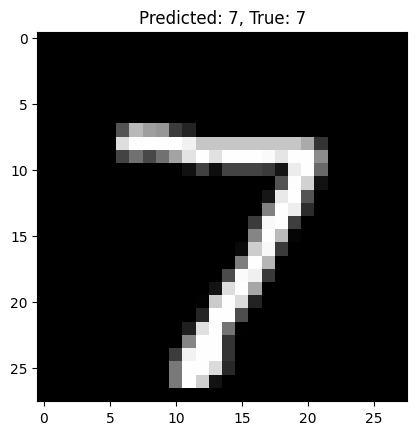

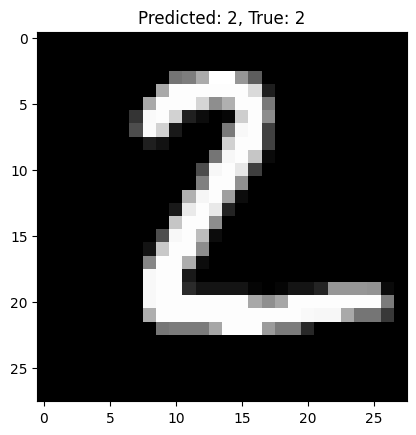

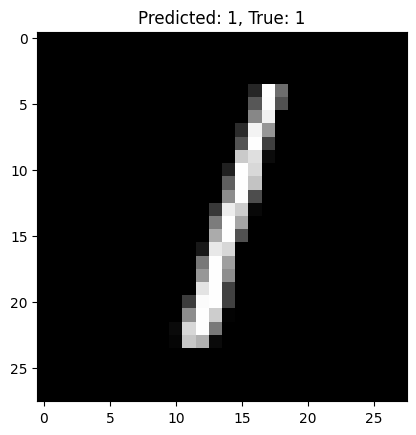

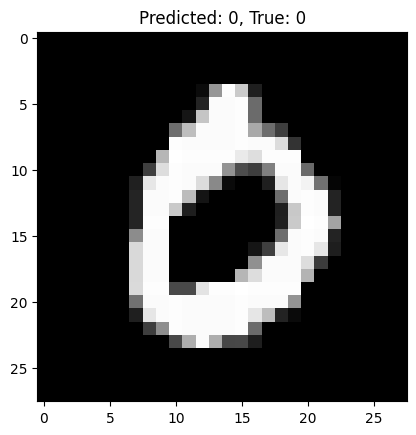

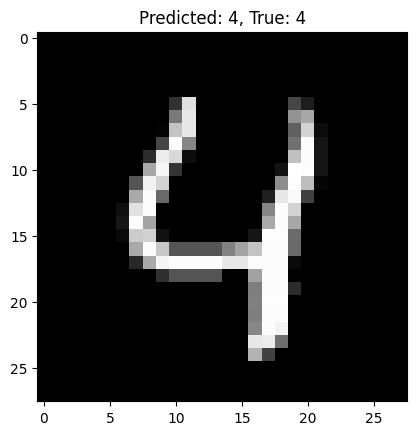

In [ ]:
#Predict on the few test samples
predictions=model.predict(x_test[:5])
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test[:5],axis=1)

for i in range(5):
  plt.imshow(x_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted: {predicted_classes[i]}, True: {true_classes[i]}")
  plt.show()